In [4]:
import pandas as pd

df = pd.read_csv("../data/StudentsPerformance.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistics:")
df.describe()

Dataset Shape: (1000, 8)

Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Data Types:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

Statistics:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
import numpy as np

df['Result'] = np.where(df['math score'] > 70, 1, 0)

df[['math score', 'Result']].head()

,math score,Result
0,72,1
1,69,0
2,90,1
3,47,0
4,76,1


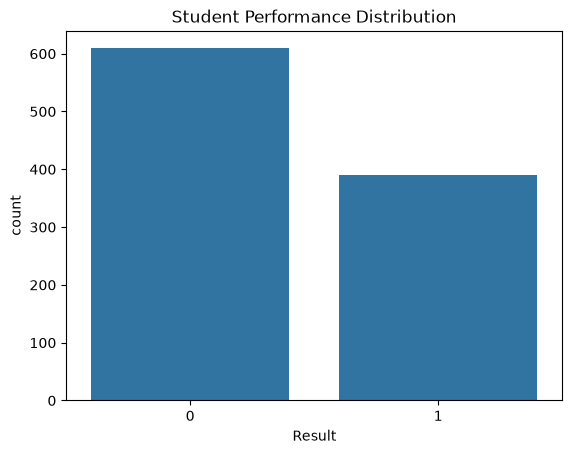

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Result', data=df)

plt.title("Student Performance Distribution")
plt.show()

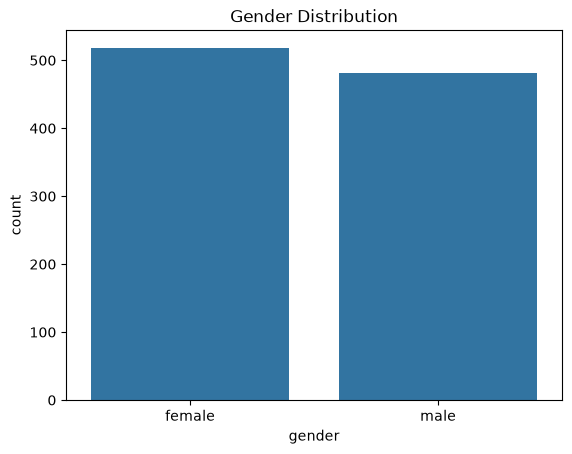

In [8]:
sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.show()

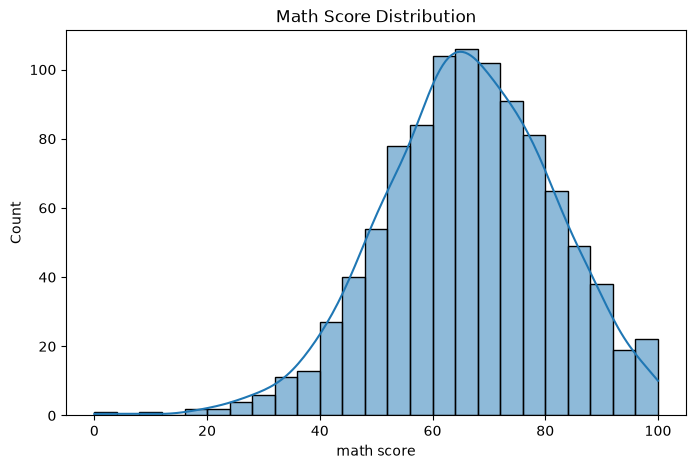

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['math score'], kde=True)

plt.title("Math Score Distribution")
plt.show()

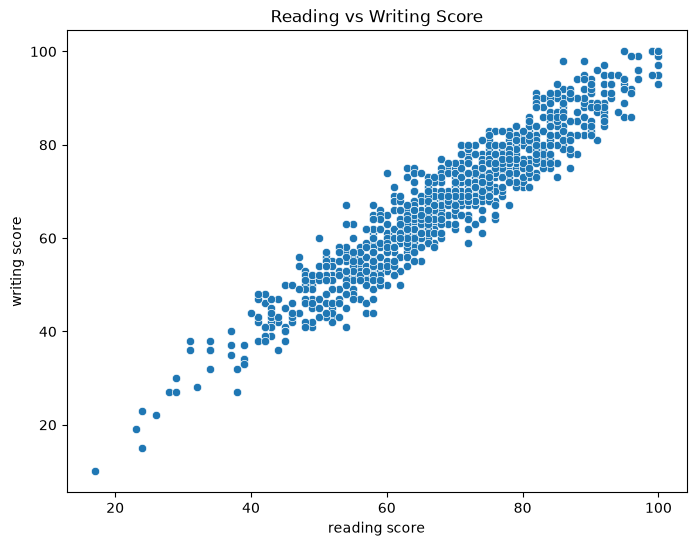

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='reading score',
    y='writing score',
    data=df
)

plt.title("Reading vs Writing Score")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

C:\Users\athar\AppData\Local\Temp\ipykernel_15736\3405490672.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Result
0,0,1,1,1,1,72,72,74,1
1,0,2,4,1,0,69,90,88,0
2,0,1,3,1,1,90,95,93,1
3,1,0,0,0,1,47,57,44,0
4,1,2,4,1,1,76,78,75,1


In [12]:
X = df.drop('Result', axis=1)

# Remove math score because Result is created from math score
X = X.drop('math score', axis=1)

y = df['Result']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 7)
Target Shape: (1000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 7)
Testing Data: (200, 7)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_acc*100, 2), "%")

Logistic Regression Accuracy: 89.5 %


In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_acc*100, 2), "%")

Decision Tree Accuracy: 83.0 %


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_acc*100, 2), "%")

Random Forest Accuracy: 87.0 %


In [17]:
import pandas as pd

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

scores = [
    lr_acc * 100,
    dt_acc * 100,
    rf_acc * 100
]

comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy (%)": scores
})

comparison_df

,Model,Accuracy (%)
0,Logistic Regression,89.5
1,Decision Tree,83.0
2,Random Forest,87.0


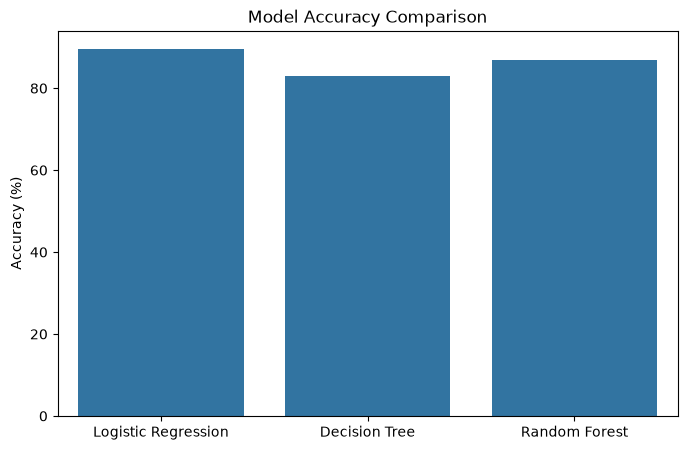

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=scores
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

In [19]:
import pickle

pickle.dump(
    lr,
    open("student_model.pkl", "wb")
)

print("Logistic Regression Model Saved Successfully!")

Logistic Regression Model Saved Successfully!


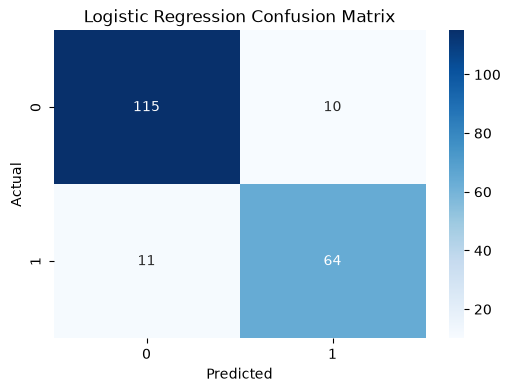

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       125
           1       0.86      0.85      0.86        75

    accuracy                           0.90       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.90      0.89       200

